### Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

### dataset loading

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Dataset Shape

In [5]:
print("Shape:", df.shape)

df.info()

Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Missing Values

In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Statistical Summary

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Visualize Data

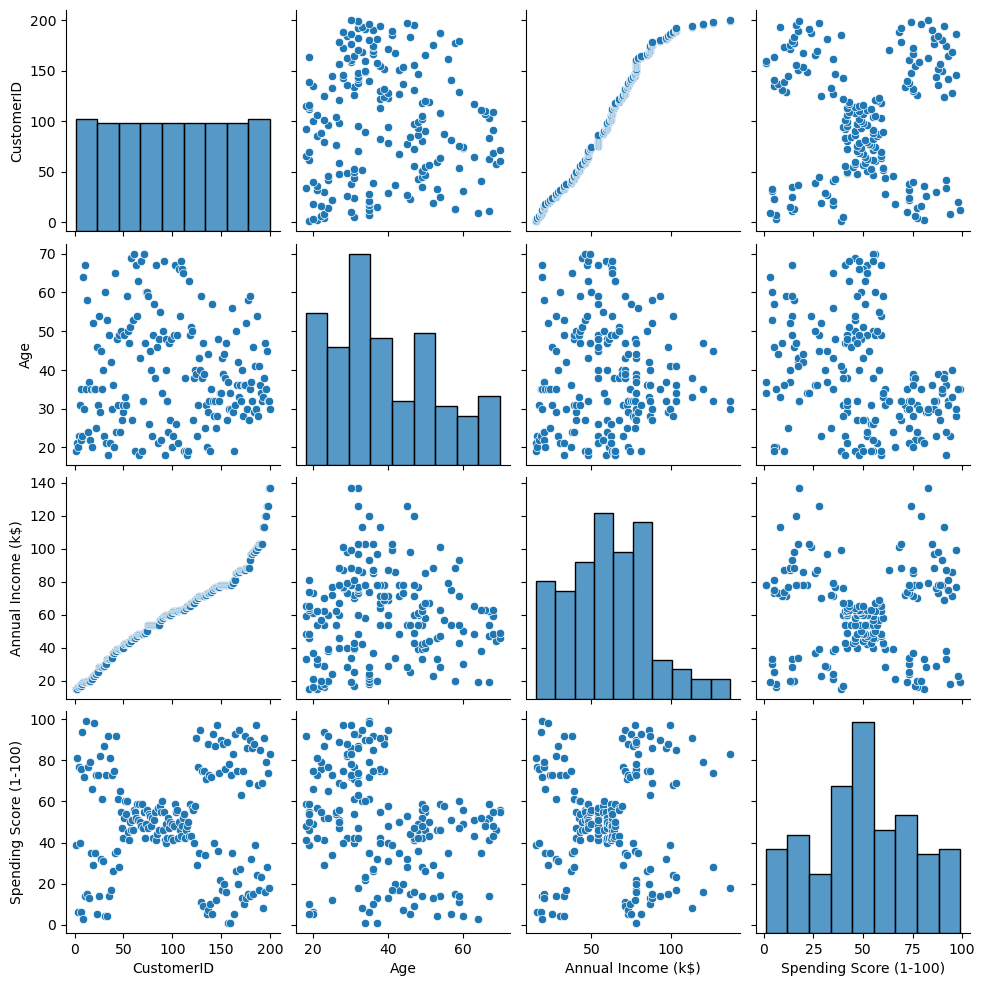

In [8]:
sns.pairplot(df)

plt.show()

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Visualize Gender Distribution

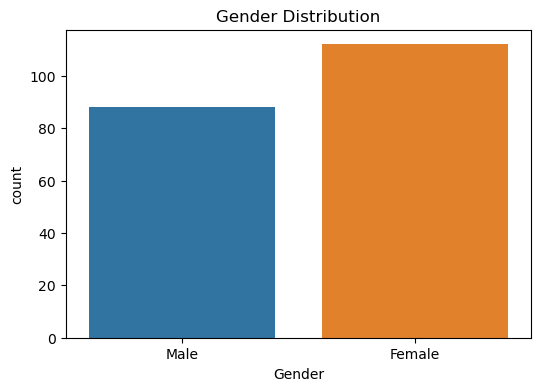

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

### Age Distribution

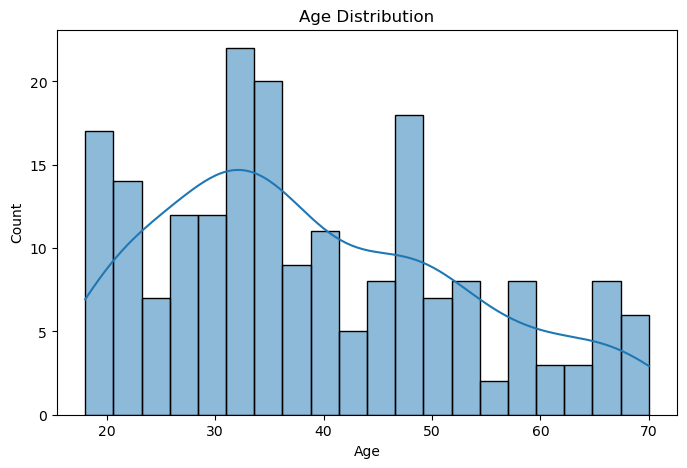

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Income vs Spending


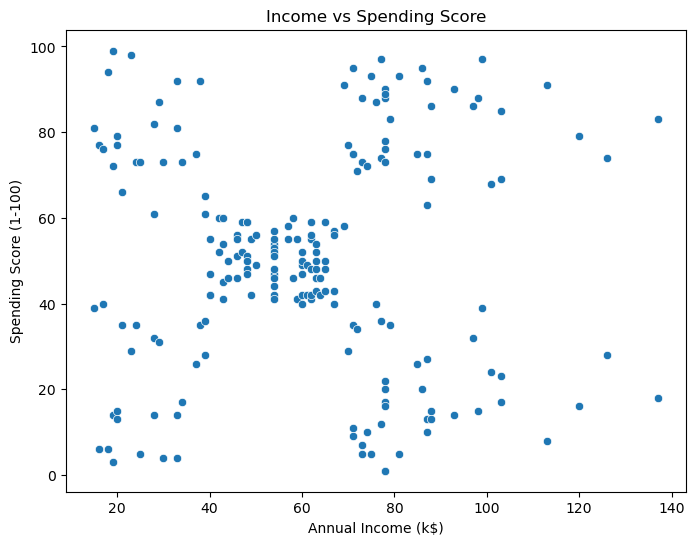

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

### Feature Selection for Clustering


In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [20]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [21]:
import sklearn
import numpy
import scipy
import threadpoolctl

print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("threadpoolctl:", threadpoolctl.__version__)

sklearn: 1.9.0
numpy: 1.26.4
scipy: 1.17.1
threadpoolctl: 3.6.0


In [22]:
import platform
print(platform.python_version())

3.11.7


### Optimal Number of Clusters (Elbow Method)

In [23]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

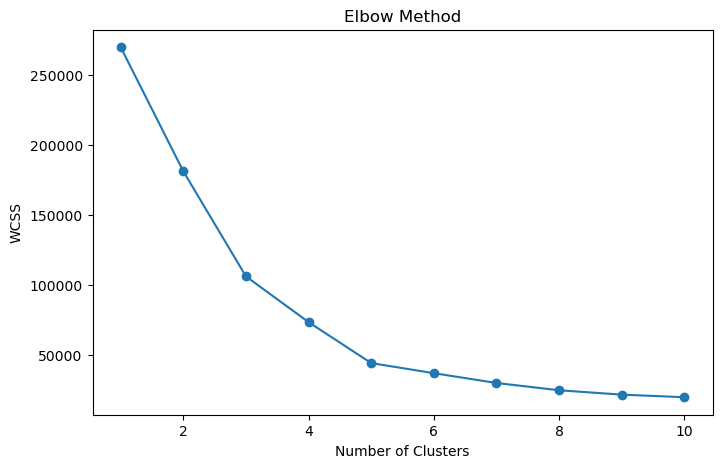

In [24]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

### Training the K-Means Model

In [25]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


### Adding Cluster Labels to Dataset

In [26]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Visualize Customer Segments

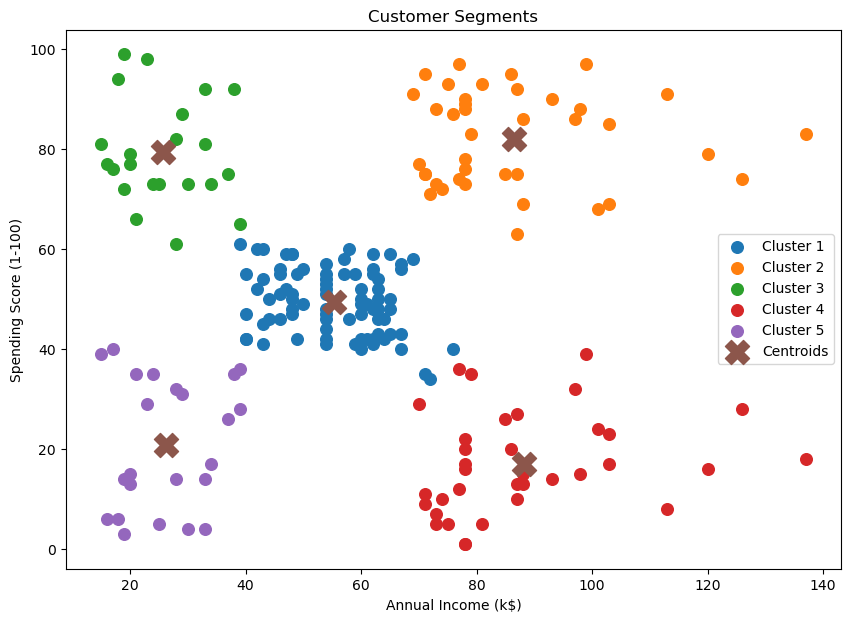

In [27]:
plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=70,
    label='Cluster 1'
)

plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=70,
    label='Cluster 2'
)

plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=70,
    label='Cluster 3'
)

plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=70,
    label='Cluster 4'
)

plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=70,
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [28]:
df.groupby('Cluster')[['Annual Income (k$)','Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Customer Labels

In [29]:
cluster_names = {
    0: "Average Customers",
    1: "Premium Customers",
    2: "Target Customers",
    3: "Careful Customers",
    4: "Low Value Customers"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer_Segment
0,1,Male,19,15,39,4,Low Value Customers
1,2,Male,21,15,81,2,Target Customers
2,3,Female,20,16,6,4,Low Value Customers
3,4,Female,23,16,77,2,Target Customers
4,5,Female,31,17,40,4,Low Value Customers


### Segment Distribution Visualization

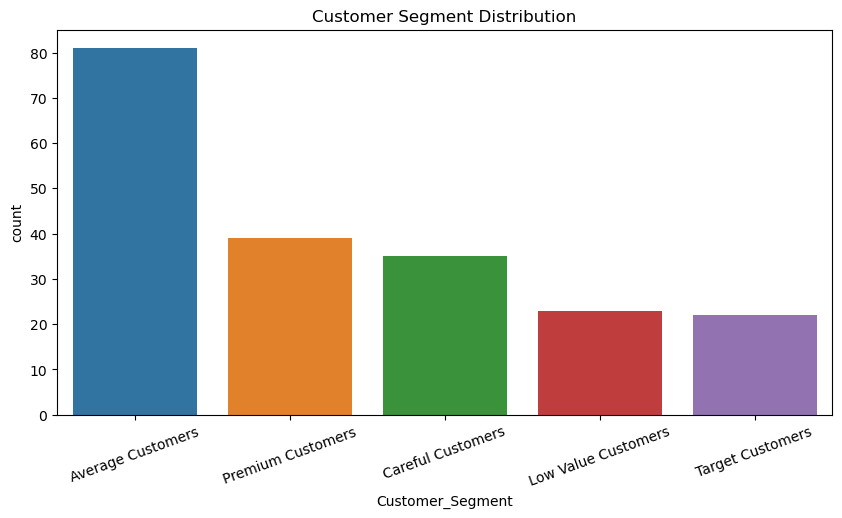

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Customer_Segment',
    data=df,
    order=df['Customer_Segment'].value_counts().index
)

plt.xticks(rotation=20)
plt.title("Customer Segment Distribution")
plt.show()

### Recommendation Engine

In [31]:
recommendations = {
    "Premium Customers":
        "Recommend luxury products, premium memberships and exclusive offers.",

    "Target Customers":
        "Recommend trending products, discounts and bundle deals.",

    "Careful Customers":
        "Recommend cashback offers and personalized promotions.",

    "Low Value Customers":
        "Recommend low-cost products and seasonal discounts.",

    "Average Customers":
        "Recommend popular products and loyalty programs."
}

In [32]:
def recommend(segment):
    return recommendations.get(segment)

for seg in recommendations:
    print(f"\n{seg}")
    print(recommend(seg))


Premium Customers
Recommend luxury products, premium memberships and exclusive offers.

Target Customers
Recommend trending products, discounts and bundle deals.

Careful Customers
Recommend cashback offers and personalized promotions.

Low Value Customers
Recommend low-cost products and seasonal discounts.

Average Customers
Recommend popular products and loyalty programs.


### Silhouette Score (Model Evaluation)

In [33]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, y_kmeans)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.554


In [34]:
df.to_csv(
    "customer_segments_output.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


### Cluster Centers Table

In [35]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centers

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


### Segment-wise Statistics

In [36]:
segment_summary = df.groupby('Customer_Segment').agg({
    'Age':['mean','min','max'],
    'Annual Income (k$)':['mean'],
    'Spending Score (1-100)':['mean']
})

segment_summary

Age         Annual Income (k$)  \
                          mean min max               mean   
Customer_Segment                                            
Average Customers    42.716049  18  70          55.296296   
Careful Customers    41.114286  19  59          88.200000   
Low Value Customers  45.217391  19  67          26.304348   
Premium Customers    32.692308  27  40          86.538462   
Target Customers     25.272727  18  35          25.727273   

                    Spending Score (1-100)  
                                      mean  
Customer_Segment                            
Average Customers                49.518519  
Careful Customers                17.114286  
Low Value Customers              20.913043  
Premium Customers                82.128205  
Target Customers                 79.363636